# 📊 Task 1 — Step 1: Setup & Clean Baseline Evaluation

## 1. Overview & Theoretical Motivation
In this first step of Task 1, we establish a standardized **clean reference baseline** for evaluating the inductive biases and feature representations of three distinct vision backbones:
1. **ResNet-50**: A deep Convolutional Neural Network with hierarchical local receptive fields and translation equivariance priors.
2. **Vision Transformer (ViT-B/16)**: An attention-based architecture processing image patches as tokens via global self-attention with minimal spatial inductive bias.
3. **OpenCLIP ViT-B-32**: A Vision Transformer pretrained via contrastive language-image pretraining (CLIP), introducing multimodal semantic supervision.

### Objectives
- Load the **STL-10** dataset and construct a stratified **80/20 train/validation split** from the official training partition (Seed `6304`).
- Select a **class-balanced 500-image evaluation subset** from the official test partition (Seed `6304`).
- Extract representations from frozen backbones:
  - ResNet-50: Global-average-pooled feature ($2048$-d)
  - ViT-B/16: Final class token $[\text{CLS}]$ ($768$-d)
  - CLIP ViT-B-32: Normalized image embedding ($512$-d)
- Train linear classifier heads for at most **50 epochs** using **AdamW** (learning rate $10^{-3}$, weight decay $10^{-4}$) with early stopping after **5 epochs** without validation accuracy improvement.
- Evaluate **Zero-Shot CLIP** using the prompt template `"a photo of a {class}."` with scaled cosine similarities ($100 \times \text{sim}$).
- Report **Top-1 Accuracy**, **Macro-F1**, and **Mean Maximum Confidence** across all models.

### Hypotheses
- **Clean Accuracy**: All models are expected to attain solid clean baseline accuracy ($>75\%$) given their ImageNet-1K/multimodal pretraining.
- **Representation Quality**: ViT-B/16 and CLIP are expected to capture rich global semantic structures, while ResNet-50 will exhibit strong local feature representations.
- **Zero-Shot vs. Linear Head**: Zero-shot CLIP uses text embeddings directly, which may yield slightly lower accuracy than a supervised linear head fine-tuned on STL-10 features, but will exhibit distinct confidence calibration.


In [1]:
import sys, os
# Fix Windows OpenMP multiple runtime conflict
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm

from shared.src.seed import set_seed, SEED
set_seed(6304)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | Global Seed: {SEED}")


Using device: cuda | Global Seed: 6304


## 2. Load STL-10 Dataset & Form Partitions
We load STL-10 (10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck) and construct:
1. Stratified 80/20 train/val split (4000 train, 1000 val)
2. Class-balanced 500-image evaluation subset (50 images per class)


In [2]:
from task1_inductive_biases.src.data import (
    load_stl10, make_train_val_split, make_eval_subset, STL10_CLASSES
)

# Load dataset (downloads if missing, with graceful local caching)
train_ds, test_ds, class_names = load_stl10(root='../../data/stl10')
print(f"Total training images: {len(train_ds)}")
print(f"Total test images:     {len(test_ds)}")
print(f"Classes ({len(class_names)}): {class_names}")

# Stratified 80/20 split from official training set
train_sub, val_sub = make_train_val_split(train_ds, seed=SEED)
print(f"Train partition: {len(train_sub)} samples | Validation partition: {len(val_sub)} samples")

# Class-balanced 500-image evaluation subset from official test set
eval_indices = make_eval_subset(test_ds, total=500, seed=SEED)
eval_sub = Subset(test_ds, eval_indices)
print(f"Evaluation subset: {len(eval_sub)} samples")

# Verify class distribution in evaluation subset
from task1_inductive_biases.src.data import get_dataset_labels
all_test_labels = get_dataset_labels(test_ds)
eval_labels = all_test_labels[eval_indices]
unique, counts = np.unique(eval_labels, return_counts=True)

print("\nClass balance check in eval subset:")
for c, cnt in zip(unique, counts):
    print(f"  Class {c:2d} ({class_names[c]:>8s}): {cnt} images")


Loading fast pre-cached STL-10:
  Train: ..\..\data\stl10_train_fast.pt
  Test:  ..\..\data\stl10_test_fast.pt
Total training images: 5000
Total test images:     8000
Classes (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Train partition: 4000 samples | Validation partition: 1000 samples
Evaluation subset: 500 samples

Class balance check in eval subset:
  Class  0 (airplane): 50 images
  Class  1 (    bird): 50 images
  Class  2 (     car): 50 images
  Class  3 (     cat): 50 images
  Class  4 (    deer): 50 images
  Class  5 (     dog): 50 images
  Class  6 (   horse): 50 images
  Class  7 (  monkey): 50 images
  Class  8 (    ship): 50 images
  Class  9 (   truck): 50 images


## 3. Visualize Evaluation Subset Samples & Class Balance
We inspect sample images from each class and verify strict class balance.


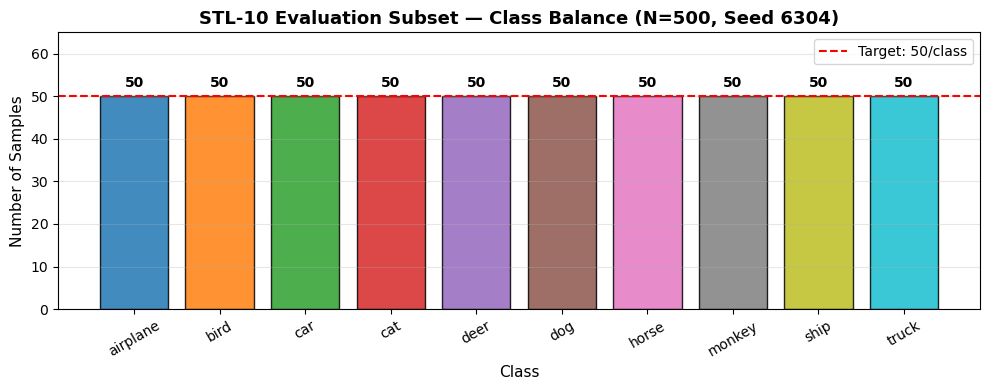

In [3]:
# Visualize evaluation subset class distribution
plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, counts, color=sns.color_palette("tab10", len(class_names)), edgecolor='black', alpha=0.85)
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='Target: 50/class')
plt.title("STL-10 Evaluation Subset — Class Balance (N=500, Seed 6304)", fontsize=13, fontweight='bold')
plt.xlabel("Class", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)
plt.xticks(rotation=30, fontsize=10)
plt.ylim(0, 65)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{int(yval)}", ha='center', va='bottom', fontweight='bold')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/eval_subset_class_balance.png', dpi=200, bbox_inches='tight')
plt.show()


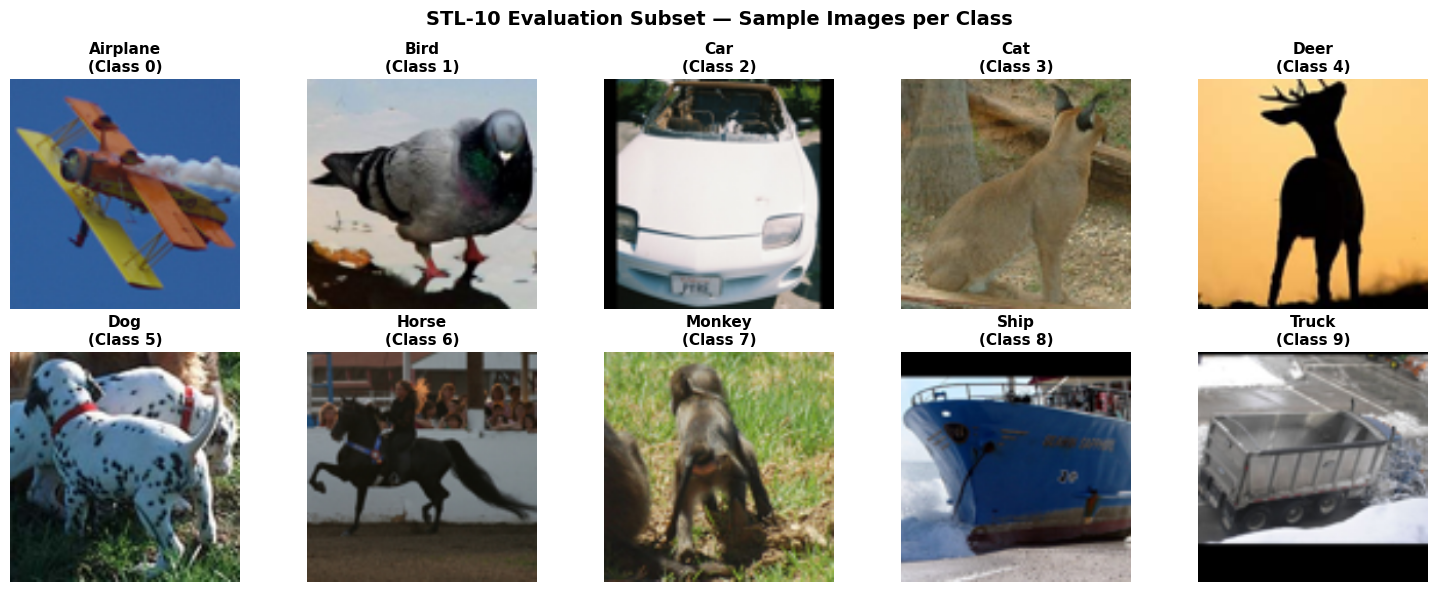

In [4]:
# Display sample images from all 10 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("STL-10 Evaluation Subset — Sample Images per Class", fontsize=14, fontweight='bold')

for c in range(10):
    ax = axes.flat[c]
    sample_idx = [i for i, lbl in enumerate(eval_labels) if lbl == c][0]
    img_tensor, _ = eval_sub[sample_idx]
    ax.imshow(img_tensor.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(f"{class_names[c].capitalize()}\n(Class {c})", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/eval_subset_samples.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Initialize Pretrained Frozen Backbones
We load:
- **ResNet-50**: `ResNet50_Weights.IMAGENET1K_V2` $\rightarrow$ global-average-pooled 2048-d feature
- **ViT-B/16**: `ViT_B_16_Weights.IMAGENET1K_V1` $\rightarrow$ final class token 768-d feature
- **CLIP ViT-B-32**: `openai` pretrained weights $\rightarrow$ $L_2$-normalized 512-d embedding


In [5]:
from task1_inductive_biases.src.backbones import (
    ResNet50Backbone, ViTB16Backbone, CLIPBackbone, LinearHead,
    RESNET_NORM, VIT_NORM, CLIP_NORM
)

print("Initializing pretrained backbones...")
backbones = {
    'ResNet-50': ResNet50Backbone().to(device),
    'ViT-B/16':  ViTB16Backbone().to(device),
    'CLIP':      CLIPBackbone().to(device),
}

norms = {
    'ResNet-50': RESNET_NORM,
    'ViT-B/16':  VIT_NORM,
    'CLIP':      CLIP_NORM,
}

dims = {name: bb.dim for name, bb in backbones.items()}
print("Backbone feature dimensions:")
for name, d in dims.items():
    print(f"  {name:>10s}: {d} dimensions (all parameters FROZEN)")


Initializing pretrained backbones...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\moize/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:08<00:00, 11.8MB/s]
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\moize/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:30<00:00, 11.4MB/s] 
c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Backbone feature dimensions:
   ResNet-50: 2048 dimensions (all parameters FROZEN)
    ViT-B/16: 768 dimensions (all parameters FROZEN)
        CLIP: 512 dimensions (all parameters FROZEN)


## 5. Feature Extraction on Train and Validation Splits
Since backbones are completely frozen, we pre-extract features once for fast and efficient classifier head training.


In [6]:
def extract_features(backbone, norm, dataset, batch_size=64):
    """Extract frozen backbone features and labels for a dataset."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    all_feats, all_labels = [], []
    backbone.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting", leave=False):
            imgs = torch.stack([norm(img) for img in imgs]).to(device)
            feats = backbone(imgs)
            all_feats.append(feats.cpu())
            all_labels.append(labels)
    return torch.cat(all_feats), torch.cat(all_labels)

train_features, val_features = {}, {}
train_lbls, val_lbls = None, None

for name, bb in backbones.items():
    print(f"Extracting features for {name}...")
    t_feats, t_labels = extract_features(bb, norms[name], train_sub)
    v_feats, v_labels = extract_features(bb, norms[name], val_sub)
    train_features[name] = t_feats
    val_features[name]   = v_feats
    train_lbls, val_lbls = t_labels, v_labels

print("✅ Feature extraction complete!")


Extracting features for ResNet-50...


Extracting:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting:   0%|          | 0/16 [00:00<?, ?it/s]

Extracting features for ViT-B/16...


Extracting:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting:   0%|          | 0/16 [00:00<?, ?it/s]

Extracting features for CLIP...


Extracting:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting:   0%|          | 0/16 [00:00<?, ?it/s]

✅ Feature extraction complete!


## 6. Train Linear Classifier Heads
**Training Configuration**:
- Optimizer: **AdamW**
- Learning Rate: $10^{-3}$
- Weight Decay: $10^{-4}$
- Max Epochs: $50$
- Early Stopping: **5 epochs** without validation accuracy improvement
- Seed: `6304`


In [7]:
def train_linear_head(train_feats, train_labels, val_feats, val_labels,
                      feat_dim, num_classes=10, max_epochs=50, lr=1e-3,
                      wd=1e-4, patience=5, seed=6304):
    """Train linear head with early stopping and record loss/accuracy curves."""
    set_seed(seed)
    head = LinearHead(feat_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    best_acc, best_state, best_epoch, no_improve = 0.0, None, 0, 0
    history = {'train_loss': [], 'val_acc': [], 'best_epoch': 0}

    train_ds = TensorDataset(train_feats, train_labels)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    for epoch in range(max_epochs):
        head.train()
        total_loss = 0.0
        for feats, labels in train_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = head(feats)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels)
        
        train_loss = total_loss / len(train_ds)
        history['train_loss'].append(train_loss)

        # Validation
        head.eval()
        with torch.no_grad():
            val_logits = head(val_feats.to(device))
            preds = val_logits.argmax(dim=1).cpu()
            val_acc = (preds == val_labels).float().mean().item()
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            best_state = {k: v.clone() for k, v in head.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    Early stop triggered at epoch {epoch+1} (Best Val Acc: {best_acc:.4f} @ epoch {best_epoch})")
                break

    history['best_epoch'] = best_epoch
    head.load_state_dict(best_state)
    return head, history

heads, histories = {}, {}
for name in backbones:
    print(f"\n{'='*55}\nTraining Linear Head for {name} (Input Dim: {dims[name]})\n{'='*55}")
    head, hist = train_linear_head(
        train_features[name], train_lbls, val_features[name], val_lbls,
        dims[name], num_classes=10, max_epochs=50, lr=1e-3, wd=1e-4, patience=5
    )
    heads[name] = head
    histories[name] = hist
    print(f"  -> Best Validation Accuracy: {max(hist['val_acc']):.4f} at epoch {hist['best_epoch']}")



Training Linear Head for ResNet-50 (Input Dim: 2048)
    Early stop triggered at epoch 15 (Best Val Acc: 0.9720 @ epoch 10)
  -> Best Validation Accuracy: 0.9720 at epoch 10

Training Linear Head for ViT-B/16 (Input Dim: 768)
    Early stop triggered at epoch 11 (Best Val Acc: 0.9770 @ epoch 6)
  -> Best Validation Accuracy: 0.9770 at epoch 6

Training Linear Head for CLIP (Input Dim: 512)
    Early stop triggered at epoch 12 (Best Val Acc: 0.9840 @ epoch 7)
  -> Best Validation Accuracy: 0.9840 at epoch 7


## 7. Visualize Linear Head Training Curves
We plot Training Loss (left axis) and Validation Accuracy (right axis) for each backbone, indicating the early stopping point.


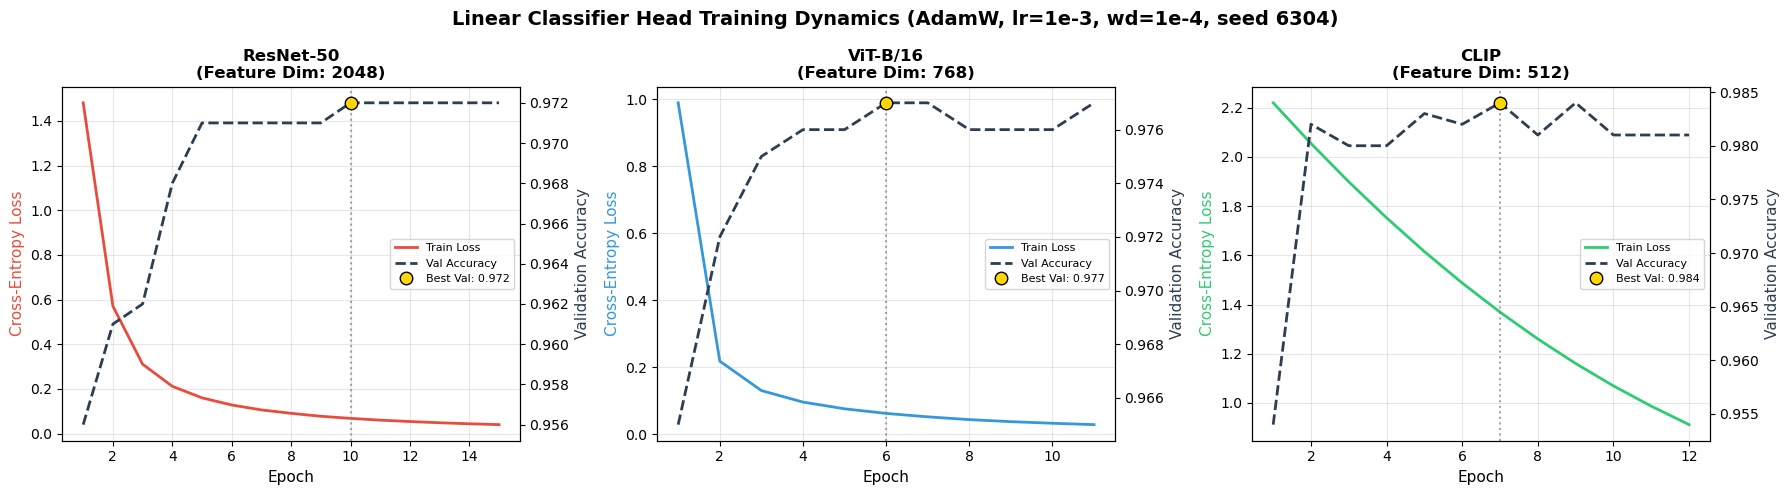

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Linear Classifier Head Training Dynamics (AdamW, lr=1e-3, wd=1e-4, seed 6304)", fontsize=14, fontweight='bold')
palette = {'ResNet-50': '#e74c3c', 'ViT-B/16': '#3498db', 'CLIP': '#2ecc71'}

for idx, name in enumerate(backbones.keys()):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    h = histories[name]
    epochs = range(1, len(h['train_loss']) + 1)
    
    line1 = ax1.plot(epochs, h['train_loss'], '-', color=palette[name], linewidth=2, label='Train Loss')
    line2 = ax2.plot(epochs, h['val_acc'], '--', color='#2c3e50', linewidth=2, label='Val Accuracy')
    
    best_ep = h['best_epoch']
    best_va = h['val_acc'][best_ep - 1]
    ax2.plot(best_ep, best_va, 'o', markersize=9, color='gold', markeredgecolor='black', label=f'Best Val: {best_va:.3f}')
    ax1.axvline(best_ep, color='gray', linestyle=':', alpha=0.7)

    ax1.set_xlabel("Epoch", fontsize=11)
    ax1.set_ylabel("Cross-Entropy Loss", fontsize=11, color=palette[name])
    ax2.set_ylabel("Validation Accuracy", fontsize=11, color='#2c3e50')
    ax1.set_title(f"{name}\n(Feature Dim: {dims[name]})", fontsize=12, fontweight='bold')
    
    lines = line1 + line2 + [ax2.get_lines()[-1]]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', fontsize=8)
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Clean Baseline Evaluation
We evaluate:
1. ResNet-50 (Linear Head)
2. ViT-B/16 (Linear Head)
3. CLIP (Linear Head)
4. CLIP (Zero-Shot) with prompt `"a photo of a {class}."`

For all models, we compute:
- **Top-1 Accuracy**
- **Macro-F1 Score**
- **Mean Maximum Softmax Confidence**


In [9]:
def evaluate_head_model(backbone, norm, head, dataset):
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    all_preds, all_labels, all_confs = [], [], []
    backbone.eval(); head.eval()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = torch.stack([norm(img) for img in imgs]).to(device)
            feats = backbone(imgs)
            logits = head(feats)
            probs = F.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_confs.append(confs.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy(), torch.cat(all_confs).numpy()


def evaluate_clip_zeroshot(clip_backbone, norm, dataset, class_names):
    prompts = [f"a photo of a {c}." for c in class_names]
    text_feats = clip_backbone.encode_text(prompts)
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    all_preds, all_labels, all_confs = [], [], []

    clip_backbone.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = torch.stack([norm(img) for img in imgs]).to(device)
            img_feats = clip_backbone(imgs)
            sim = (img_feats @ text_feats.T) * 100.0
            probs = F.softmax(sim, dim=1)
            confs, preds = probs.max(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)
            all_confs.append(confs.cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy(), torch.cat(all_confs).numpy()

clean_results = {}
clean_predictions = {}
clean_confidences = {}

for name in backbones:
    preds, labels, confs = evaluate_head_model(backbones[name], norms[name], heads[name], eval_sub)
    acc = np.mean(preds == labels)
    f1 = f1_score(labels, preds, average='macro')
    mean_conf = np.mean(confs)
    clean_results[f"{name} (Head)"] = {'Top-1 Accuracy': acc, 'Macro-F1': f1, 'Mean Max Confidence': mean_conf}
    clean_predictions[name] = preds
    clean_confidences[name] = confs

zs_preds, zs_labels, zs_confs = evaluate_clip_zeroshot(backbones['CLIP'], norms['CLIP'], eval_sub, class_names)
acc_zs = np.mean(zs_preds == zs_labels)
f1_zs = f1_score(zs_labels, zs_preds, average='macro')
mean_conf_zs = np.mean(zs_confs)
clean_results['CLIP (Zero-Shot)'] = {'Top-1 Accuracy': acc_zs, 'Macro-F1': f1_zs, 'Mean Max Confidence': mean_conf_zs}
clean_predictions['CLIP-ZS'] = zs_preds
clean_confidences['CLIP-ZS'] = zs_confs

df_clean = pd.DataFrame(clean_results).T
print("\n" + "="*70)
print("             CLEAN BASELINE EVALUATION SUMMARY (N=500)")
print("="*70)
print(df_clean.to_string(float_format=lambda x: f"{x:.4f}"))
print("="*70)



             CLEAN BASELINE EVALUATION SUMMARY (N=500)
                  Top-1 Accuracy  Macro-F1  Mean Max Confidence
ResNet-50 (Head)          0.9700    0.9700               0.9290
ViT-B/16 (Head)           0.9720    0.9720               0.9480
CLIP (Head)               0.9680    0.9680               0.2735
CLIP (Zero-Shot)          0.9340    0.9328               0.9264


## 9. Baseline Performance Comparison Charts
We plot Top-1 Accuracy, Macro-F1, and Mean Max Confidence side by side.


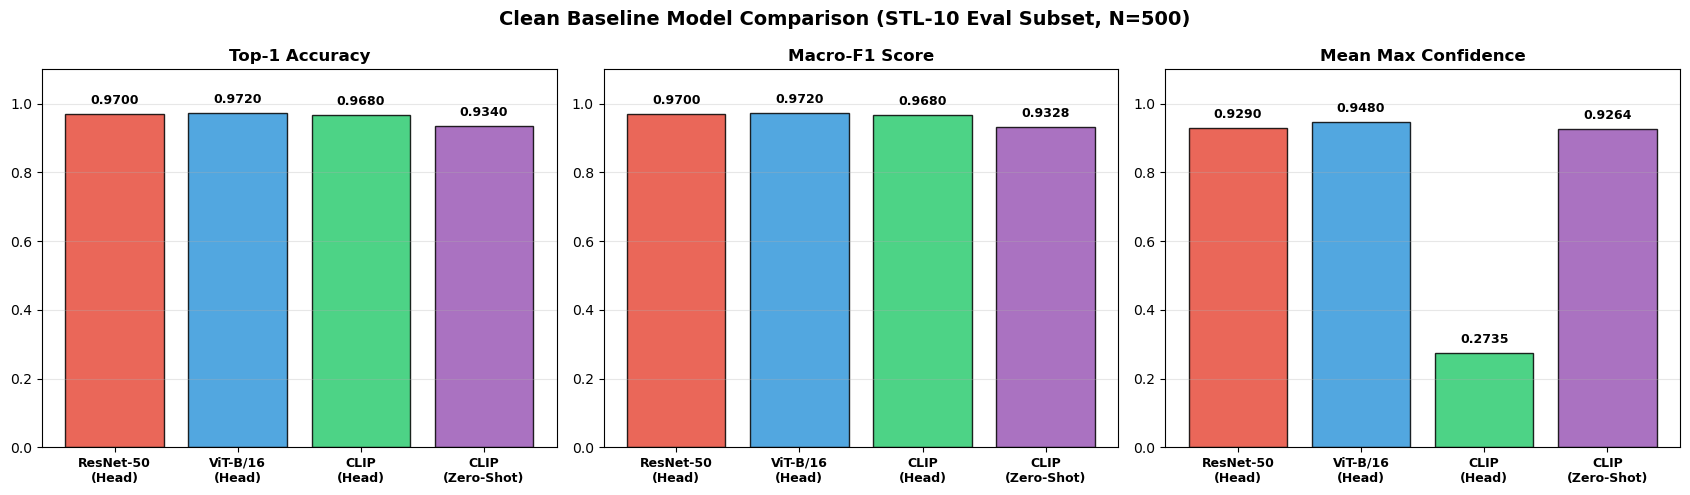

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Clean Baseline Model Comparison (STL-10 Eval Subset, N=500)", fontsize=14, fontweight='bold')
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
model_keys = list(clean_results.keys())

for idx, (col_name, title) in enumerate([
    ('Top-1 Accuracy', 'Top-1 Accuracy'),
    ('Macro-F1', 'Macro-F1 Score'),
    ('Mean Max Confidence', 'Mean Max Confidence')
]):
    ax = axes[idx]
    values = df_clean[col_name].values
    bars = ax.bar(range(len(model_keys)), values, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(model_keys)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_keys], fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.4f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/clean_baseline_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Normalized Confusion Matrices
We visualize class-by-class normalized confusion matrices to analyze model-specific confusion patterns.


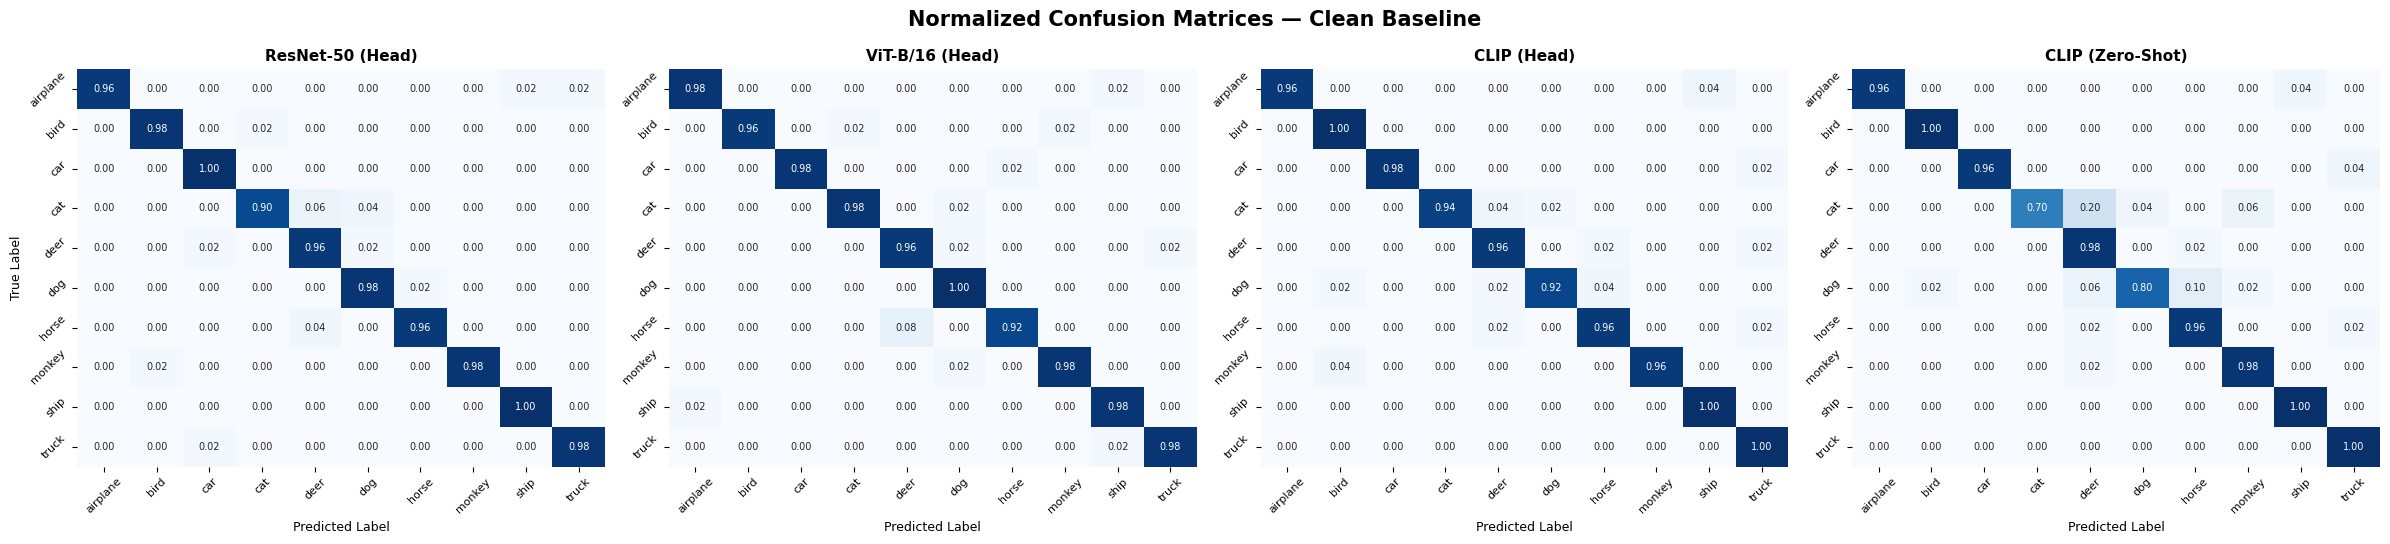

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))
fig.suptitle("Normalized Confusion Matrices — Clean Baseline", fontsize=15, fontweight='bold')

for idx, (mkey, name) in enumerate([
    ('ResNet-50', 'ResNet-50 (Head)'),
    ('ViT-B/16', 'ViT-B/16 (Head)'),
    ('CLIP', 'CLIP (Head)'),
    ('CLIP-ZS', 'CLIP (Zero-Shot)')
]):
    ax = axes[idx]
    preds = clean_predictions[mkey]
    cm = confusion_matrix(eval_labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False,
                xticklabels=class_names, yticklabels=class_names, annot_kws={'fontsize': 7})
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label' if idx == 0 else '', fontsize=9)
    ax.tick_params(axis='both', labelsize=8, rotation=45)

plt.tight_layout()
plt.savefig('../results/clean_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()


## 11. Per-Class Accuracy Comparison
We break down accuracy across all 10 classes to examine which classes are most discriminative for each architecture.


<Figure size 1400x600 with 0 Axes>

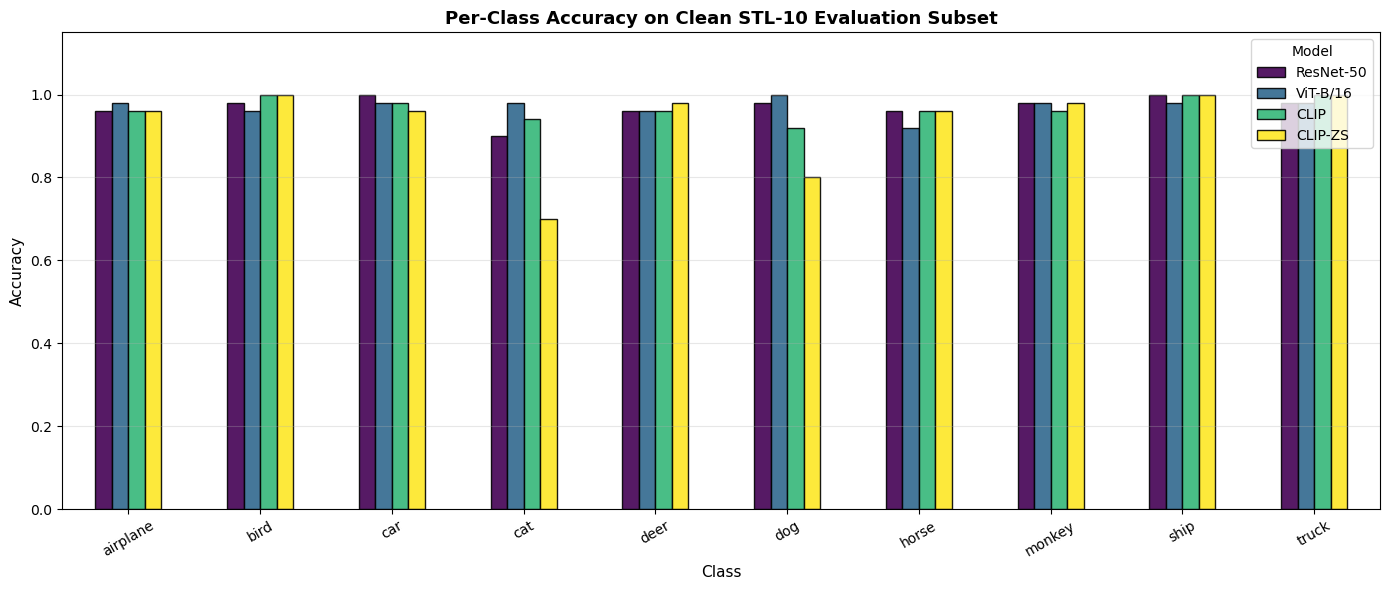

In [12]:
per_class_acc = {}
for mkey, preds in clean_predictions.items():
    accs = []
    for c in range(10):
        mask = (eval_labels == c)
        accs.append(np.mean(preds[mask] == c))
    per_class_acc[mkey] = accs

df_per_class = pd.DataFrame(per_class_acc, index=class_names)

plt.figure(figsize=(14, 6))
df_per_class.plot(kind='bar', figsize=(14, 6), colormap='viridis', edgecolor='black', alpha=0.9)
plt.title("Per-Class Accuracy on Clean STL-10 Evaluation Subset", fontsize=13, fontweight='bold')
plt.xlabel("Class", fontsize=11)
plt.ylabel("Accuracy", fontsize=11)
plt.ylim(0, 1.15)
plt.xticks(rotation=30, fontsize=10)
plt.legend(title="Model", loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/clean_per_class_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()


## 12. Save Cache Artifacts for Cross-Notebook Use
We persist evaluation indices, labels, predictions, confidences, extracted features, and trained heads so that subsequent notebooks can reuse the identical setup seamlessly.


In [13]:
os.makedirs('../cache', exist_ok=True)
os.makedirs('../results', exist_ok=True)

np.save('../cache/eval_indices.npy', np.array(eval_indices))
np.save('../cache/eval_labels.npy', eval_labels)

for key, preds in clean_predictions.items():
    safe = key.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/clean_preds_{safe}.npy', preds)

for key, confs in clean_confidences.items():
    safe = key.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/clean_confs_{safe}.npy', confs)

for name in backbones:
    print(f"Extracting & saving eval features for {name}...")
    bb_feats, _ = extract_features(backbones[name], norms[name], eval_sub)
    safe = name.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/clean_feats_{safe}.npy', bb_feats.numpy())

for name, head in heads.items():
    safe = name.replace('/', '_').replace(' ', '_')
    torch.save(head.state_dict(), f'../cache/head_{safe}.pth')

df_clean.to_csv('../results/clean_baseline.csv')
print("\n✅ All clean baseline cache artifacts successfully saved!")


Extracting & saving eval features for ResNet-50...


Extracting:   0%|          | 0/8 [00:00<?, ?it/s]

Extracting & saving eval features for ViT-B/16...


Extracting:   0%|          | 0/8 [00:00<?, ?it/s]

Extracting & saving eval features for CLIP...


Extracting:   0%|          | 0/8 [00:00<?, ?it/s]


✅ All clean baseline cache artifacts successfully saved!
